In [20]:
!pip install gensim

In [21]:
import numpy as np
import pandas as pd
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

from gensim.models import Word2Vec

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [22]:
import numpy as np
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from gensim.models import Word2Vec

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Download stopwords
nltk.download('stopwords')

# DATASET

texts = [

    # POSITIVE
    "Amazing movie with great acting",
    "I loved this film",
    "Fantastic story and wonderful music",
    "Brilliant performance by actors",
    "The movie was excellent",

    # NEUTRAL
    "The movie was okay",
    "It was an average film",
    "The story was normal",
    "Nothing special in the movie",
    "The acting was fine",

    # NEGATIVE
    "Terrible movie and boring story",
    "I hated this film",
    "Worst acting ever",
    "The movie was very bad",
    "Completely waste of time"
]

# 0 = Negative
# 1 = Neutral
# 2 = Positive
labels = np.array([


    2,2,2,2,2,


    1,1,1,1,1,


    0,0,0,0,0
])

print("Labels:")
print(labels)

ps = PorterStemmer()

cleaned_texts = []

for text in texts:


    review = re.sub('[^a-zA-Z]', ' ', text)


    review = review.lower()

    review = review.split()

    review = [
        ps.stem(word)
        for word in review
        if word not in stopwords.words('english')
    ]

    cleaned_texts.append(review)

print("\nPreprocessed Text:")
print(cleaned_texts)

# TRAIN WORD2VEC MODEL

w2v_model = Word2Vec(
    cleaned_texts,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4
)

# FUNCTION TO CONVERT SENTENCE TO VECTOR

def get_vector(sentence):

    # Preprocess sentence
    sentence = re.sub('[^a-zA-Z]', ' ', sentence)
    sentence = sentence.lower()
    sentence = sentence.split()

    sentence = [
        ps.stem(word)
        for word in sentence
        if word not in stopwords.words('english')
    ]

    vectors = []

    for word in sentence:

        if word in w2v_model.wv:
            vectors.append(w2v_model.wv[word])

    # If sentence empty
    if len(vectors) == 0:
        return np.zeros(100)

    # Average vectors
    return np.mean(vectors, axis=0)


#FEATURE MATRIX

X = np.array([
    get_vector(' '.join(text))
    for text in cleaned_texts
])

print("\nFeature Shape:")
print(X.shape)


# FFNN MODEL


model = Sequential()

# Hidden Layer
model.add(Dense(
    16,
    activation='relu',
    input_shape=(100,)
))

# Output Layer for 3 classes
model.add(Dense(
    3,
    activation='softmax'
))

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# TRAIN MODEL

model.fit(
    X,
    labels,
    epochs=100,
    verbose=0
)

# TEST NEW SENTENCE


new_text = "The movie was average"

# Convert to vector
new_vec = get_vector(new_text).reshape(1, -1)

# Predict
prediction = model.predict(new_vec)

# Get class index
predicted_class = np.argmax(prediction)

print("\nPrediction Probabilities:")
print(prediction)

# PRINT SENTIMENT

if predicted_class == 2:
    print("Positive Review")

elif predicted_class == 1:
    print("Neutral Review")

else:
    print("Negative Review")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Labels:
[2 2 2 2 2 1 1 1 1 1 0 0 0 0 0]

Preprocessed Text:
[['amaz', 'movi', 'great', 'act'], ['love', 'film'], ['fantast', 'stori', 'wonder', 'music'], ['brilliant', 'perform', 'actor'], ['movi', 'excel'], ['movi', 'okay'], ['averag', 'film'], ['stori', 'normal'], ['noth', 'special', 'movi'], ['act', 'fine'], ['terribl', 'movi', 'bore', 'stori'], ['hate', 'film'], ['worst', 'act', 'ever'], ['movi', 'bad'], ['complet', 'wast', 'time']]

Feature Shape:
(15, 100)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step

Prediction Probabilities:
[[0.32922772 0.33968082 0.33109143]]
Neutral Review


In [23]:
history = model.fit(
    X,
    labels,
    epochs=100,
    verbose=0,
    validation_split=0.2
)

In [24]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# Convert cleaned text back to string (IMPORTANT)
bow_texts = [
    " ".join(text) for text in cleaned_texts
]

# Create BoW model
vectorizer = CountVectorizer()

bow_matrix = vectorizer.fit_transform(bow_texts).toarray()

# Get feature names (words)
words = vectorizer.get_feature_names_out()

#vocabulary
print("BAG OF WORDS VOCAB")
print(words)

#matrix
print("BAG OF WORDS MATRIX")
print(bow_matrix)


BAG OF WORDS VOCAB
['act' 'actor' 'amaz' 'averag' 'bad' 'bore' 'brilliant' 'complet' 'ever'
 'excel' 'fantast' 'film' 'fine' 'great' 'hate' 'love' 'movi' 'music'
 'normal' 'noth' 'okay' 'perform' 'special' 'stori' 'terribl' 'time'
 'wast' 'wonder' 'worst']
BAG OF WORDS MATRIX
[[1 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1 0]
 [0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 

In [25]:
!pip install matplotlib seaborn scikit-learn

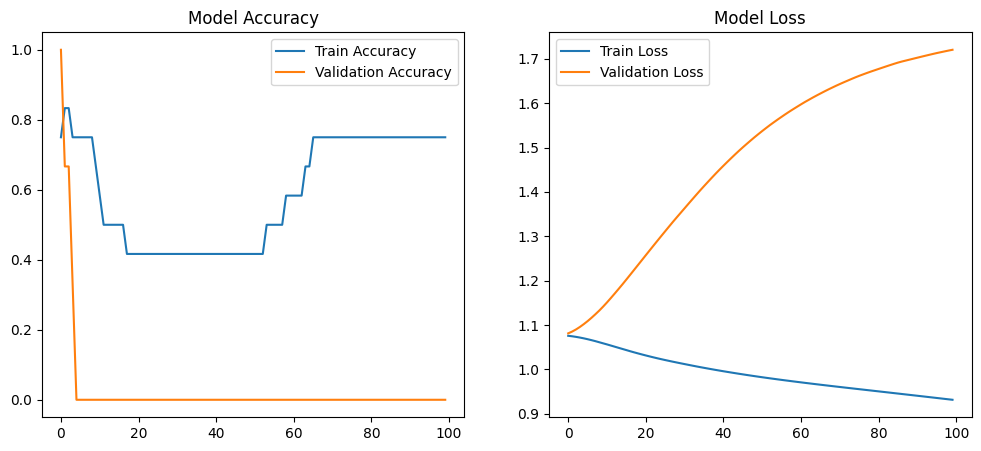

In [26]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.legend()

plt.show()

In [27]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np

#all words from Word2Vec model
words = list(w2v_model.wv.index_to_key)

#word vectors
word_vectors = np.array([w2v_model.wv[word] for word in words])

print("Total words:", len(words))
print("Vector shape:", word_vectors.shape)

Total words: 29
Vector shape: (29, 100)
